# 미니프로젝트: 결측치·이상치·클래스 불균형 처리 (Vibe Coding)

#### <목표>
오늘 배운 **결측치/이상치 처리, Under/Oversampling, SVDD**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Telco Customer Churn (통신사 고객 이탈 데이터)
- 고객의 인적사항, 가입 서비스, 요금·계약 정보와 이탈(Churn) 여부를 담은 데이터

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 고객 정보로 이탈 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day4_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

**[과제]** 써니는 통신사 고객 이탈 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 호출하고 데이터를 불러와 구조를 확인하는 코드를 AI와 상의해서 작성하세요.

In [50]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# 평가 지표
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import warnings

In [51]:
data = pd.read_csv('dataset/day4_miniproject.csv')
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11.0,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


## 1) 데이터 탐색 (EDA)

### 1-1) 기본 EDA 진행

**[과제]** 써니는 데이터 분석 전, 데이터의 구조적 및 통계적 정보가 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [ ]:
[프롬프트]

나는 데이터셋을 "data"라는 이름으로 불러왔어.

이 데이터에 대한 구조적, 통계적 정보가 궁금한데
확인할 수 있는 방법 추천해주고 코드 작성해줘.

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            6832 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6903 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     6832 non-null   object 


In [53]:
data.describe(include = "all")

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043.000000,7043,7043,6832.000000,7043,7043,6903,7043,7043,7043,7043,7043,7043,7043,7043,6832,6832.000000,7032.000000,7043
unique,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,3555,NaN,3641,4933,NaN,6361,3390,3033,3498,3088,3095,3473,2810,2785,3875,4171,2296,NaN,NaN,5174
mean,NaN,0.162147,NaN,NaN,32.376903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.758255,2283.300441,NaN
std,NaN,0.368612,NaN,NaN,24.570605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.077758,2266.771362,NaN
min,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.587500,401.450000,NaN
50%,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,NaN


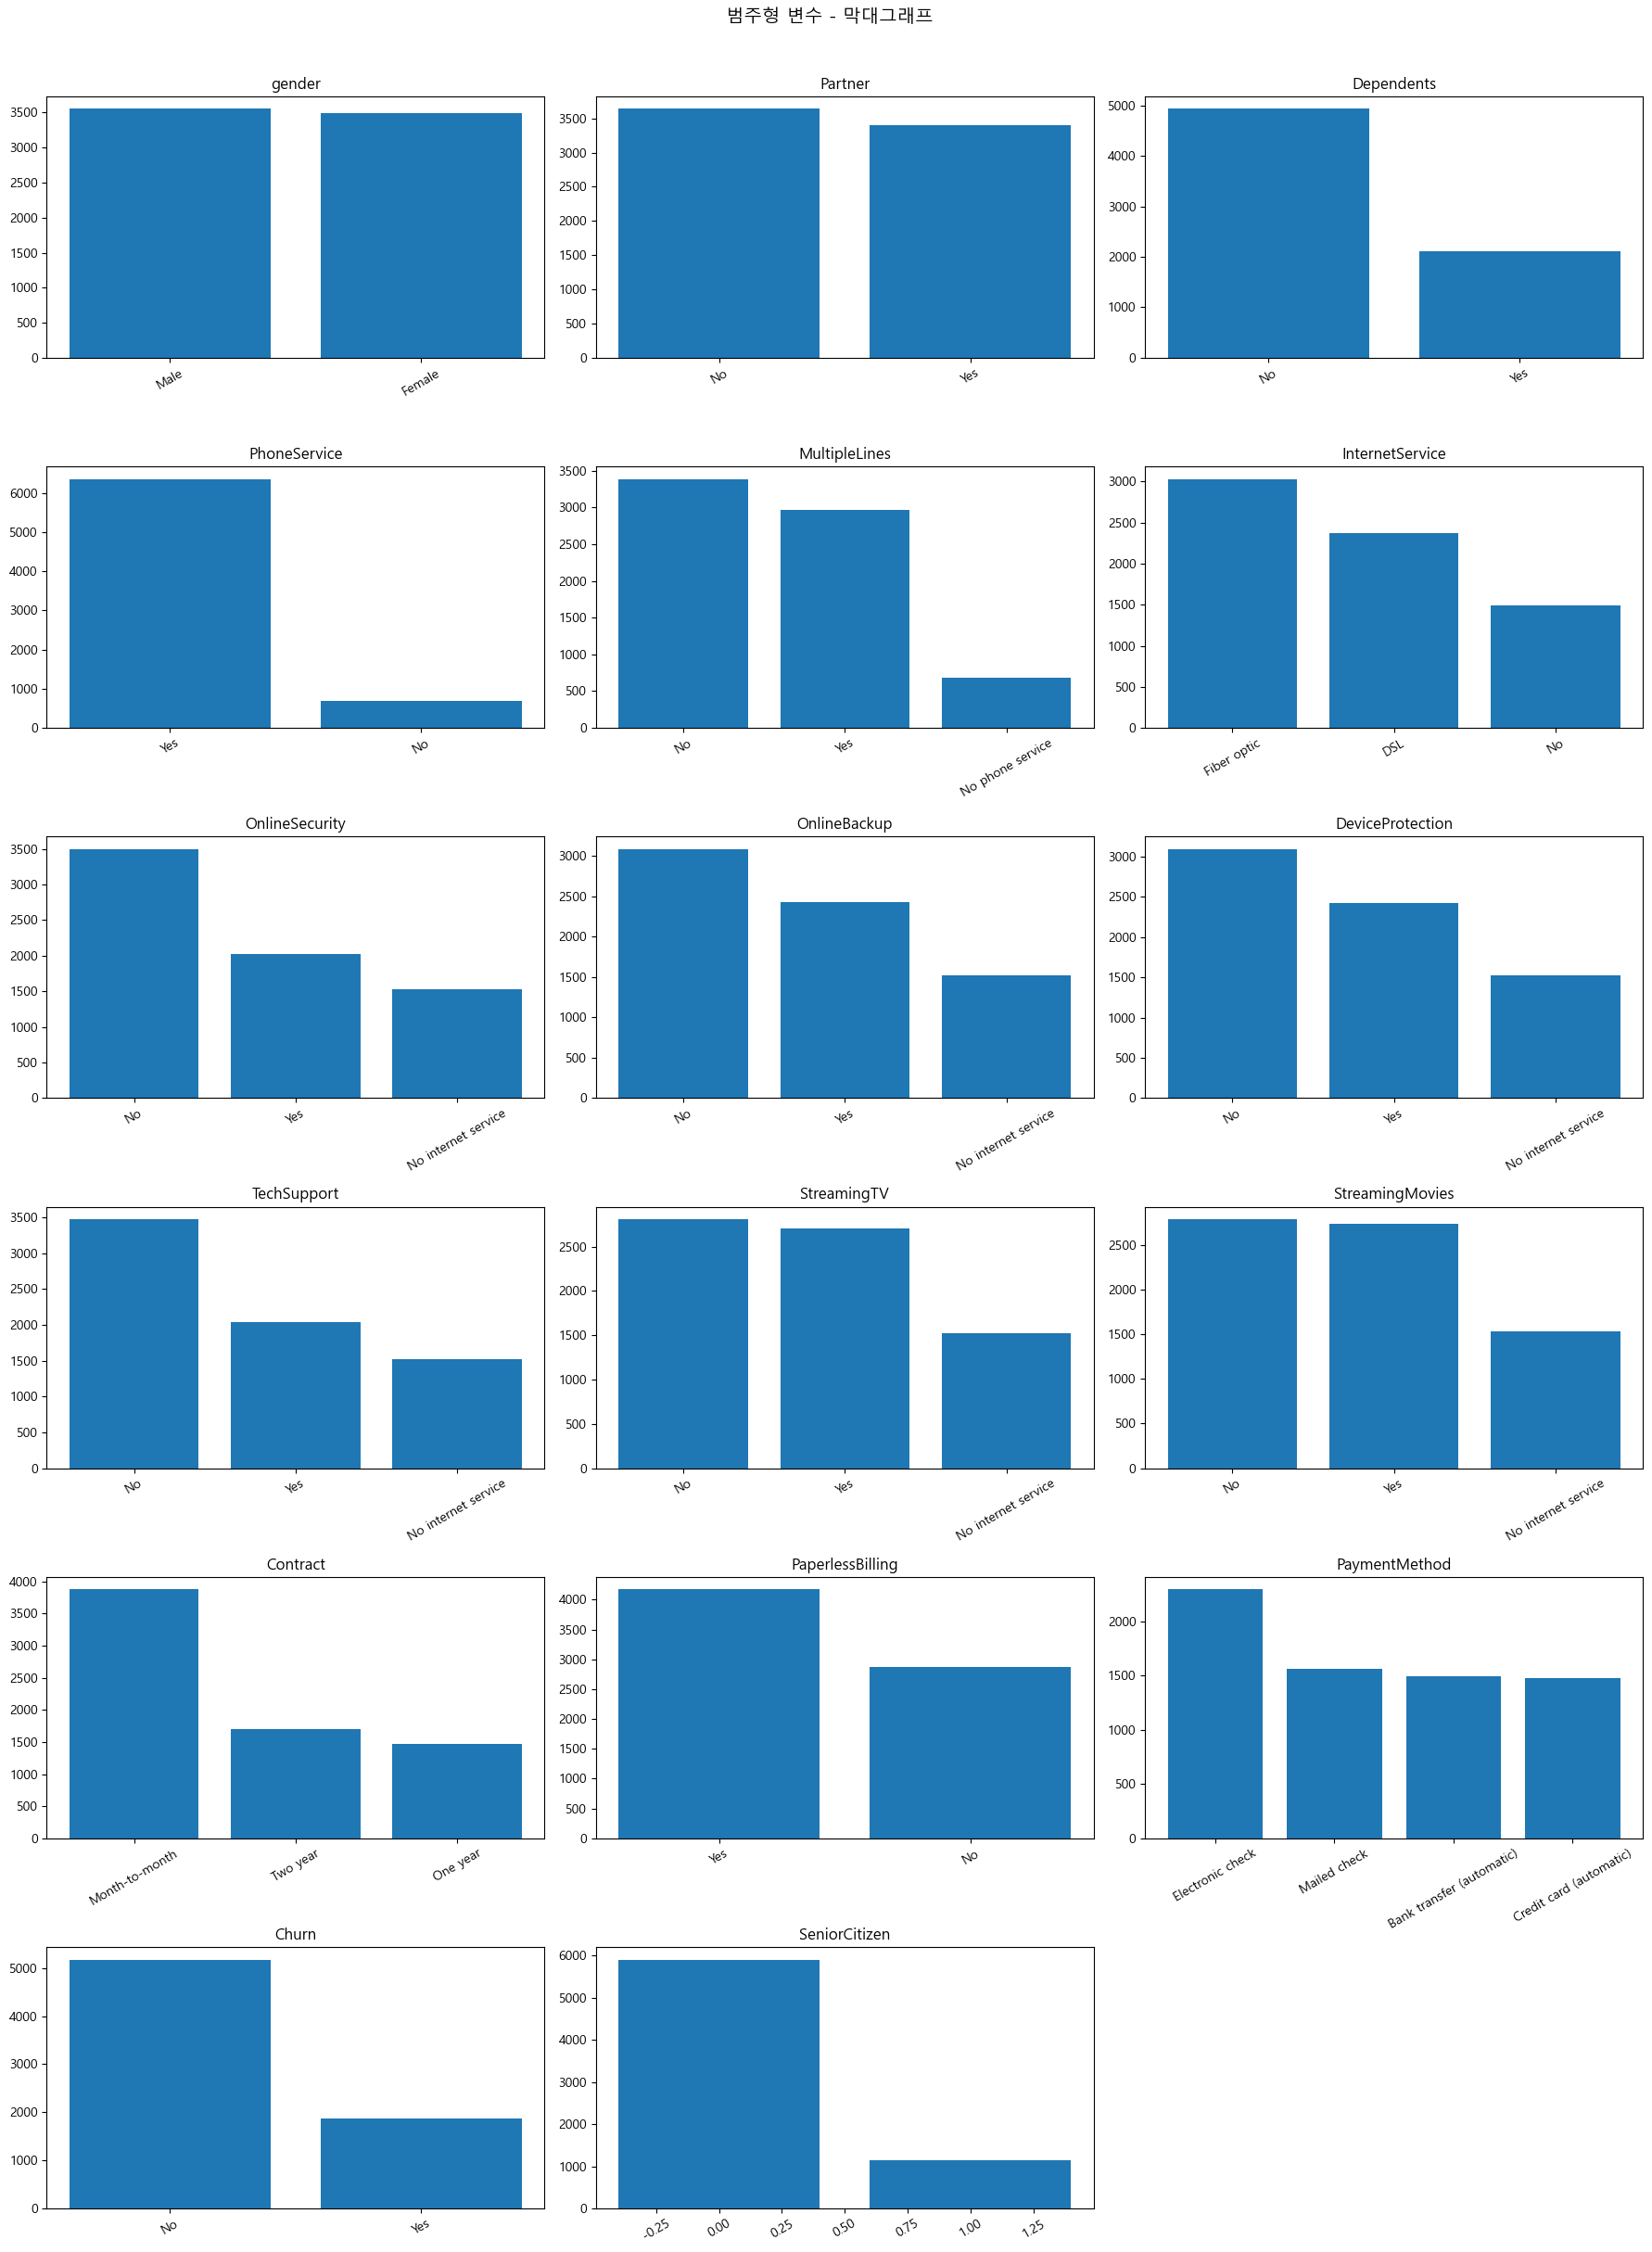

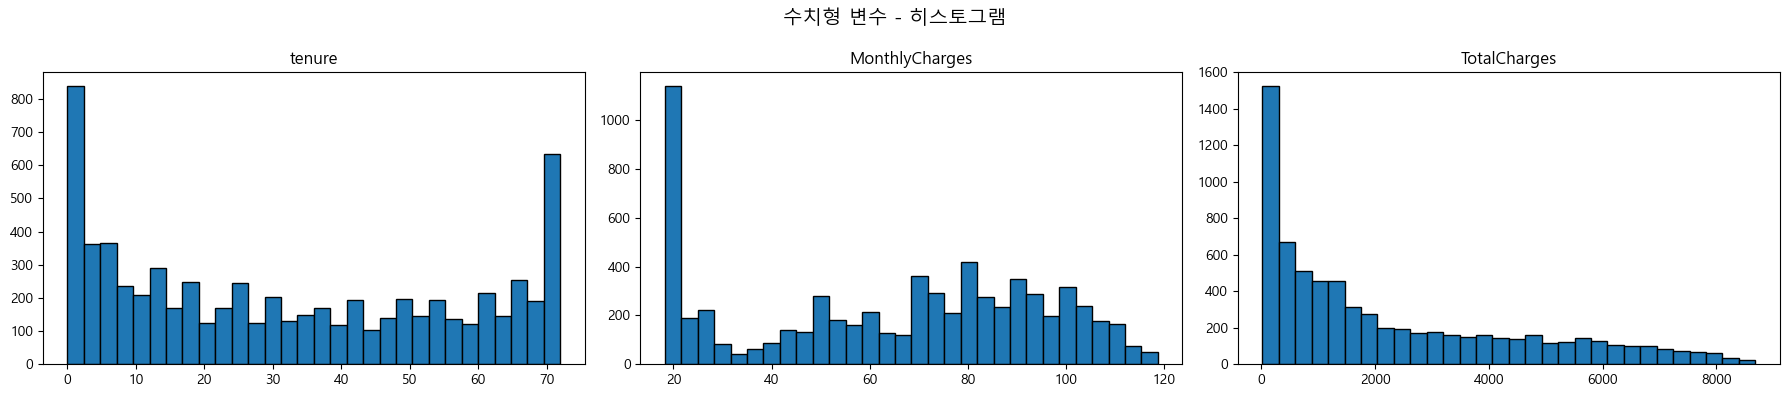

In [54]:
# 컬럼 분류
categorical_cols = data.select_dtypes(include='object').columns.tolist()
categorical_cols += ['SeniorCitizen']  # 0/1 이진 변수 → 범주형으로 처리
numeric_cols = [col for col in data.select_dtypes(include=['float64', 'int64']).columns
                if col not in categorical_cols]

# ── 범주형: 막대그래프 ──────────────────────────────────────────
n_cat = len(categorical_cols)
fig, axes = plt.subplots(nrows=(n_cat + 2) // 3, ncols=3, figsize=(18, 4 * ((n_cat + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = data[col].value_counts(dropna=True)
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('범주형 변수 - 막대그래프', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── 수치형: 히스토그램 ──────────────────────────────────────────
n_num = len(numeric_cols)
fig, axes = plt.subplots(nrows=1, ncols=n_num, figsize=(6 * n_num, 4))
if n_num == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(col)

plt.suptitle('수치형 변수 - 히스토그램', fontsize=14)
plt.tight_layout()
plt.show()

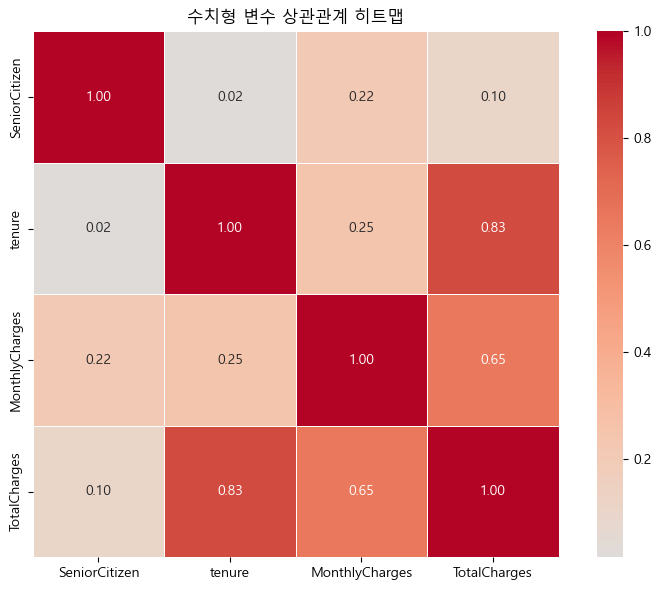

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

corr = data[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('수치형 변수 상관관계 히트맵')
plt.tight_layout()
plt.show()

**[과제]** 써니는 EDA를 통해 전처리가 필요한 부분을 발견했습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

> Tip: 'Churn' 변수의 타입이나 값 표기 방식

In [ ]:
[프롬프트]

EDA 과정 중에서 타깃변수인 Churn이 object 형태였어.
이걸 적절하게 처리할 수 있는 방법을 추천해주고 코드 작성해줘.

In [56]:
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11.0,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


### 1-2) 결측치 현황 파악

**[과제]** 써니는 데이터에 결측치가 존재하는지, 존재한다면 어떤 형태로 얼마나 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [ ]:
[프롬프트]

data에 결측치가 존재하는지 궁금해. 관련 코드 작성해줘.

In [57]:
# 컬럼별 결측치 개수 및 비율
missing = data.isnull().sum()
missing_ratio = data.isnull().mean() * 100

missing_df = pd.DataFrame({
    '결측치 수': missing,
    '결측치 비율(%)': missing_ratio.round(2)
})

print(missing_df[missing_df['결측치 수'] > 0])

                 결측치 수  결측치 비율(%)
tenure             211       3.00
InternetService    140       1.99
PaymentMethod      211       3.00
MonthlyCharges     211       3.00
TotalCharges        11       0.16


### 1-3) 클래스 불균형 확인

**[과제]** 써니는 Churn 비율이 얼마나 불균형한지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [ ]:
[프롬프트]

Churn이라는 타깃변수의 불균형 정도가 궁금해. 관련 코드 작성해줘.

In [59]:
# 클래스별 빈도 및 비율
churn_counts = data['Churn'].value_counts()
churn_ratio = data['Churn'].value_counts(normalize=True) * 100

print("=== Churn 클래스 분포 ===")
print(pd.DataFrame({'빈도': churn_counts, '비율(%)': churn_ratio.round(2)}))

=== Churn 클래스 분포 ===
         빈도  비율(%)
Churn             
0      5174  73.46
1      1869  26.54


### 1-4) 이상치 후보 탐색

**[과제]** 써니는 수치형 변수에 이상치가 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [ ]:
[프롬프트]

data의 수치형 변수에 이상치가 존재하는지 궁금해. 관련 코드 작성해줘.

In [60]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# ── IQR 기반 이상치 개수 출력 ──────────────────────────────────
print("=== IQR 기반 이상치 탐지 ===")
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)][col]
    print(f"{col}: 이상치 {len(outliers)}개 | 범위 [{lower:.2f}, {upper:.2f}]")

=== IQR 기반 이상치 탐지 ===
tenure: 이상치 0개 | 범위 [-60.00, 124.00]
MonthlyCharges: 이상치 0개 | 범위 [-45.81, 171.24]
TotalCharges: 이상치 0개 | 범위 [-4688.48, 8884.67]


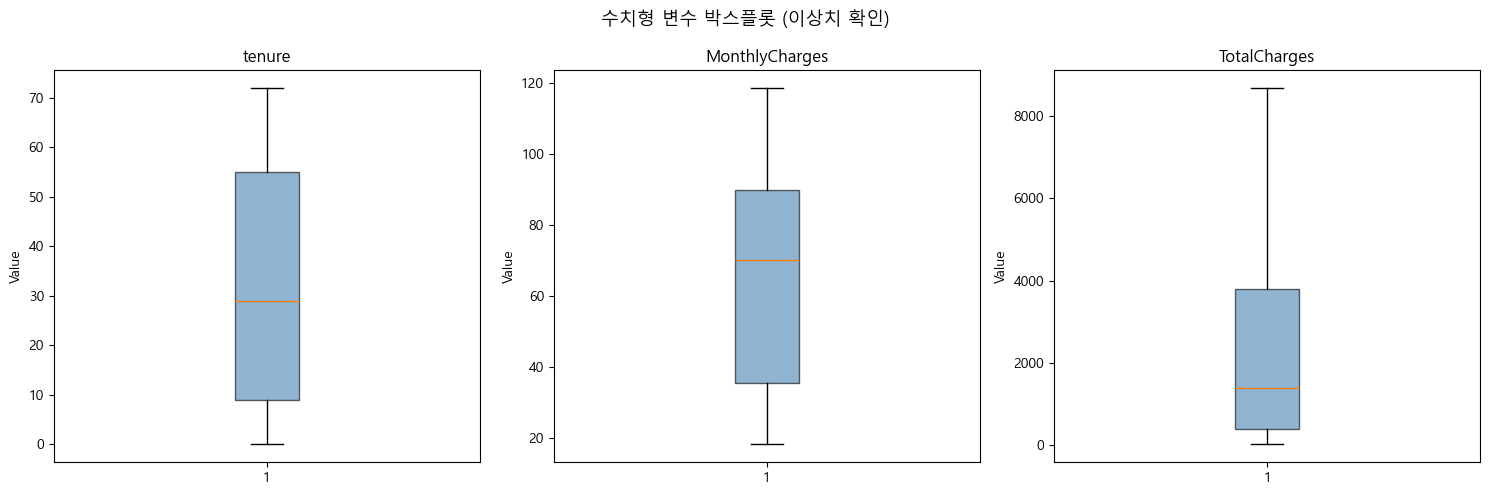

In [61]:
# ── 박스플롯 시각화 ────────────────────────────────────────────
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 5))

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(data[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('수치형 변수 박스플롯 (이상치 확인)', fontsize=13)
plt.tight_layout()
plt.show()

## 2) 결측치 처리

**[과제]** 써니는 데이터셋에 존재하는 결측치를 제거하거나 대치하려 합니다.

이때 변수마다 분포나 특성이 다르면 적합한 대치법도 달라질 수 있다고 생각합니다.

AI와 상의하여 변수별로 제거와 대치 중 어떤 방법이 적합한지 결정하고, 대치를 선택했다면 값 기반, 통계 기반(평균/중앙값/최빈값), 머신러닝 기반(KNN Imputer) 중 어떤 방식이 적합한지 정하여 적용해보세요.

In [ ]:
[프롬프트]

결측치를 대치하려고 하는데

1. 결측치가 존재하는 변수의 type을 볼 수 있는 코드 작성해줘.
2. 내가 1에 대한 결과를 주면 값 기반, 통계기반, KNN Imputer 중에 변수별로 가장 적합한 전처리 방법을 이유와 함께 추천해줘.

In [62]:
missing_cols = data.columns[data.isnull().any()].tolist()
print(data[missing_cols].dtypes)

tenure             float64
InternetService     object
PaymentMethod       object
MonthlyCharges     float64
TotalCharges       float64
dtype: object


| 컬럼 | 타입 | 추천 방법 | 이유 |
|---|---|---|---|
| `tenure` | float64 | KNN Imputer | `MonthlyCharges`, `TotalCharges`와 상관관계가 높아 주변 이웃 정보 활용이 정확함 |
| `MonthlyCharges` | float64 | KNN Imputer | `tenure`, `TotalCharges`와 연관성이 강해 KNN이 유리 |
| `TotalCharges` | float64 | 통계 기반 (중앙값) | 결측치가 11개로 매우 적고, right-skewed 분포라 평균보다 중앙값이 안정적 |
| `InternetService` | object | 값 기반 (최빈값) | 범주형은 KNN/통계 기반 적용 불가, 최빈값이 표준적인 대치 방법 |
| `PaymentMethod` | object | 값 기반 (최빈값) | 동일하게 범주형이므로 최빈값 대치 |

In [63]:
from sklearn.impute import KNNImputer

# ── 0. Train/Test 먼저 분리 ──────────────────────────────────────────────
X = data.drop(columns='Churn')
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [64]:
# ── 1. 범주형 → 최빈값 대치 (train 기준) ─────────────────────
for col in ['InternetService', 'PaymentMethod']:
    mode_val = X_train[col].mode()[0]           # train에서만 최빈값 계산
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col]  = X_test[col].fillna(mode_val)

# ── 2. TotalCharges → 중앙값 대치 (train 기준) ───────────────
median_val = X_train['TotalCharges'].median()   # train에서만 중앙값 계산
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(median_val)
X_test['TotalCharges']  = X_test['TotalCharges'].fillna(median_val)

# ── 3. tenure, MonthlyCharges → KNN Imputer (train 기준) ─────
knn_cols = ['tenure', 'MonthlyCharges']
imputer = KNNImputer(n_neighbors=5)
X_train[knn_cols] = imputer.fit_transform(X_train[knn_cols])  # fit은 train만
X_test[knn_cols]  = imputer.transform(X_test[knn_cols])       # test는 transform만

# ── 확인 ─────────────────────────────────────────────────────
print(X_train[['tenure', 'InternetService', 'PaymentMethod',
               'MonthlyCharges', 'TotalCharges']].isnull().sum())

tenure             0
InternetService    0
PaymentMethod      0
MonthlyCharges     0
TotalCharges       0
dtype: int64


## 3) 이상치 처리

**[과제]** 써니는 데이터셋에 존재하는 이상치를 제거하고자 합니다.

다만 이탈(Churn) 고객이 실제로는 "정상 범위를 벗어난" 요금 및 이용 패턴을 가진 고객일 수 있다는 점이 마음에 걸립니다. 이상치 제거가 소수 클래스(Churn)를 함께 지워버릴 위험은 없는지 AI와 상의하여 검토하고 안전한 처리 기준을 정해 적용해 보세요.

In [ ]:
* 이상치가 없으니까 pass *

## 4) 데이터 분할 및 스케일링/인코딩

**[과제]** 써니는 모델 구축 전 학습/테스트 데이터를 나누려고 합니다. 클래스 불균형이 심한 상황에서 어떤 분할 방법이 적합할지 AI와 상의해서 정하고 나눠 보세요.

In [ ]:
* 결측치 처리 시 이미 했으므로 pass *

**[과제]** 써니는 분할한 학습/테스트 데이터에 적절한 스케일링 및 인코딩을 적용하고자 합니다. AI와 상의하여 수치형 변수와 범주형 변수 각각에 적합한 스케일링 및 인코딩 방식을 정하고 적용해보세요.

In [ ]:
[프롬프트]

데이터의 수치형 변수와 범주형 변수에 적절한 스케일링와 인코딩 기법을 적용하고 싶어.

1. 각각 이유와 함께 추천해주고
2. 1에 대한 결정이 나랑 끝나면 관련 코드 작성해줘.

| 구분 | 컬럼 | 추천 방법 | 이유 |
|---|---|---|---|
| 스케일링 | `tenure`, `MonthlyCharges`, `TotalCharges` | StandardScaler | 이상치 없고 정규분포에 가까운 형태라 표준화가 안정적 |
| 스케일링 | `SeniorCitizen` | 불필요 | 이미 0/1 이진값 |
| 인코딩 | `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling` | Label Encoding (0/1 매핑) | 값이 2개인 이진 변수 → 0/1로 충분 |
| 인코딩 | `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaymentMethod` | One-Hot Encoding | 값이 3개 이상인 명목형 변수 → Label Encoding 시 순서 오해 가능 |

In [65]:
from sklearn.preprocessing import StandardScaler

# ── 1. Label Encoding (이진 범주형) ───────────────────────────
binary_map = {
    'gender':           {'Male': 1, 'Female': 0},
    'Partner':          {'Yes': 1, 'No': 0},
    'Dependents':       {'Yes': 1, 'No': 0},
    'PhoneService':     {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map.items():
    X_train[col] = X_train[col].map(mapping)
    X_test[col]  = X_test[col].map(mapping)

# ── 2. One-Hot Encoding (다중 범주형) ─────────────────────────
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=False)
X_test  = pd.get_dummies(X_test,  columns=ohe_cols, drop_first=False)

# train/test 컬럼 불일치 방지
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# ── 3. StandardScaler (수치형) ────────────────────────────────
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

## 5) 클래스 불균형 시각화 및 Resampling 적용

**[과제]** 써니는 Churn 여부에 따라 고객들의 데이터가 얼마나 잘 구분되는지 궁금합니다. t-SNE로 학습 데이터를 2차원에 시각화하여 두 클래스가 얼마나 겹쳐 있는지 AI와 함께 코드를 작성하고 분석해보세요.

In [ ]:
[프롬프트]

t-SNE를 그려서 Churn 여부에 따라 고객들의 데이터가 얼마나 구분되는지가 궁금해.
시각화하는 코드 작성해줘.

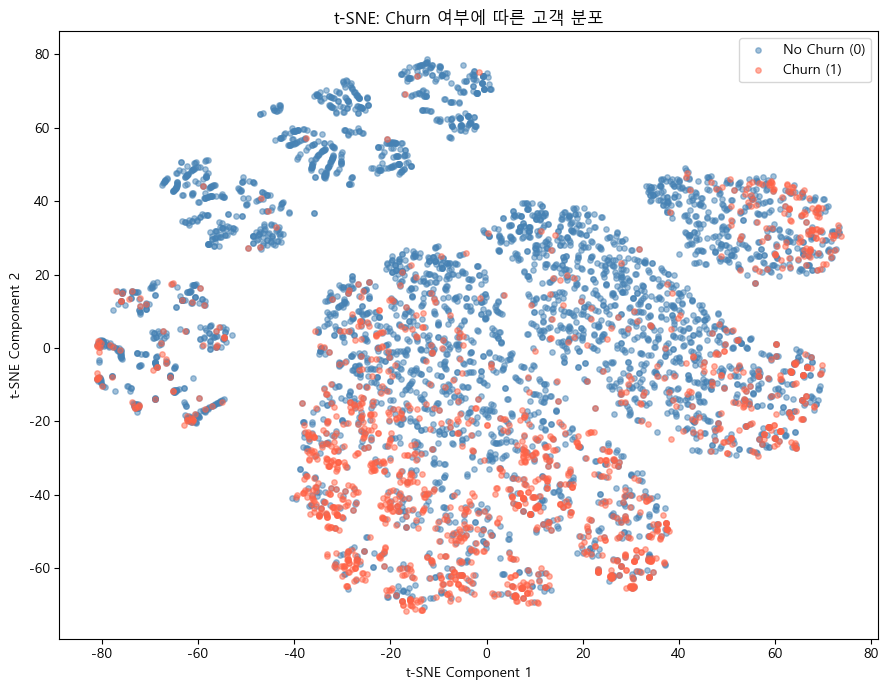

In [82]:
from sklearn.manifold import TSNE

# t-SNE 학습 (train 데이터 기준, 샘플 수가 많으면 시간이 걸릴 수 있음)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_train.astype(float))

# 시각화
plt.figure(figsize=(9, 7))
colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'No Churn (0)', 1: 'Churn (1)'}

for cls in [0, 1]:
    idx = y_train == cls
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                c=colors[cls], label=labels[cls],
                alpha=0.5, s=15)

plt.title('t-SNE: Churn 여부에 따른 고객 분포')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.tight_layout()
plt.show()

**[과제]** 써니는 클래스 불균형을 완화하기 위해 여러 Resampling 기법(TomekLinks, SMOTE, SMOTE+TomekLinks, ADASYN)을 학습 데이터에 적용해보고 t-SNE로 데이터 분포가 어떻게 변하는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

> Tip: Resampling은 학습 데이터에만 적용하고, 테스트 데이터는 원본 그대로 유지할 것

In [ ]:
[프롬프트]

클래스 불균형을 해결하기 위해서
TomekLinks, SMOTE, SMOTE+TomeLinks, ADASYN을 적용해보고 싶은데

1. 학습 데이터에만 적용하는 코드 작성해주고
2. 데이터가 어떻게 변화하는지 dataframe 형태로만 보여주는 코드 작성해줘.

In [66]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [67]:
# ── 1. 각 방법론 적용 (train만) ───────────────────────────────
methods = {
    'Original':          (X_train, y_train),
    'TomekLinks':        TomekLinks().fit_resample(X_train, y_train),
    'SMOTE':             SMOTE(random_state=42).fit_resample(X_train, y_train),
    'SMOTE+TomekLinks':  SMOTETomek(random_state=42).fit_resample(X_train, y_train),
    'ADASYN':            ADASYN(random_state=42).fit_resample(X_train, y_train),
}

In [69]:
# ── 2. 클래스 분포 변화 DataFrame으로 출력 ────────────────────
rows = []
for name, (X_r, y_r) in methods.items():
    counts = y_r.value_counts()
    total  = len(y_r)
    rows.append({
        'Method':      name,
        'No Churn (0)': counts.get(0, 0),
        'Churn (1)':    counts.get(1, 0),
        'Total':        total,
        'Ratio (0:1)':  f"{counts.get(0,0)/total*100:.1f}% : {counts.get(1,0)/total*100:.1f}%"
    })

result_df = pd.DataFrame(rows).set_index('Method')
result_df

,No Churn (0),Churn (1),Total,Ratio (0:1)
Method,,,,
Original,4139,1495,5634,73.5% : 26.5%
TomekLinks,3773,1495,5268,71.6% : 28.4%
SMOTE,4139,4139,8278,50.0% : 50.0%
SMOTE+TomekLinks,3984,3984,7968,50.0% : 50.0%
ADASYN,4139,4106,8245,50.2% : 49.8%


**[과제]** 써니는 Resampling 기법별로 분류 모델(예: XGBoost)을 학습시켜 성능을 비교하려고 합니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [ ]:
[프롬프트]

앞에서 말한 Resampling 방법 4가지에 따라
학습 데이터를 Resampling하고 XGBoost를 학습시켰을 때
성능이 어떠한지 비교하고 싶어.

관련 코드 작성해줘.

In [70]:
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

In [71]:
# ── 평가 함수 ─────────────────────────────────────────────────
def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Method':    name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob), 4),
    }

In [73]:
# ── Resampling 방법 4가지 + Original ─────────────────────────
results = []

for name, (X_r, y_r) in methods.items():
    model = XGBClassifier(n_estimators = 100, random_state=42, verbosity=0)
    model.fit(X_r, y_r)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append(evaluate(name, y_test, y_pred, y_prob))

# ── 결과 출력 ─────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('Method')
results_df

,Accuracy,Precision,Recall,F1,AUC-ROC
Method,,,,,
Original,0.7850,0.6086,0.5321,0.5678,0.8220
TomekLinks,0.7715,0.5663,0.5936,0.5796,0.8082
SMOTE,0.7651,0.5521,0.6096,0.5794,0.8140
SMOTE+TomekLinks,0.7651,0.5523,0.6070,0.5783,0.8147
ADASYN,0.7708,0.5612,0.6257,0.5917,0.8136


## 6) SVDD (One-Class SVM) 적용

**[과제]** 써니는 Resampling 방식 대신, 정상(Non-Churn) 데이터만으로 정상 영역을 학습하는 One-Class Learning 접근은 성능이 어떨지 궁금해졌습니다. AI와 함께 One-Class SVM(SVDD)을 정상 데이터로만 학습시키고 Churn 샘플이 그 경계 밖으로 얼마나 잘 걸러지는지 코드를 작성하고 분석해보세요.

> Tip: 정상 데이터로만 학습하고 테스트는 정상/이상 모두 진행

In [ ]:
[프롬프트]

Resampling 하지말고 SVDD 적용하는 코드 작성해줘.

In [75]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()

In [77]:
from sklearn.svm import OneClassSVM

# 이탈 고객(Churn=1)만 추출하여 SVDD 학습
X_churn = X_train[y_train == 1]

svdd = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
svdd.fit(X_churn)

# SVDD 예측: +1 → Churn(1), -1 → No Churn(0) 으로 변환
y_pred_svdd = svdd.predict(X_test)
y_pred_binary = (y_pred_svdd == 1).astype(int)

get_classscore(y_test, y_pred_binary)

Accuracy  : 0.578
Precision : 0.376
Recall    : 0.896
F1-score  : 0.530



**[과제]** 써니는 `nu` 값에 따라 SVDD의 경계와 성능이 어떻게 달라지는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

In [ ]:
[프롬프트]

nu 값에 따라 SVDD 경계랑 성능이 어떻게 달라지는지 궁금해.
가장 좋은 nu를 선택하고 싶어.

관련 코드 작성해줘.

In [78]:
nu_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

# ── nu별 성능 비교 ─────────────────────────────────────────────
rows = []
for nu in nu_values:
    model = OneClassSVM(kernel='rbf', nu=nu, gamma='scale')
    model.fit(X_train[y_train == 1])

    y_pred = (model.predict(X_test) == 1).astype(int)
    f1 = f1_score(y_test, y_pred)
    rows.append({'nu': nu, 'F1-score': round(f1, 4)})

result_df = pd.DataFrame(rows).set_index('nu')
print(result_df)

# ── 최적 nu 선택 ───────────────────────────────────────────────
best_nu = result_df['F1-score'].idxmax()
print(f"\n최적 nu: {best_nu}  (F1-score: {result_df.loc[best_nu, 'F1-score']})")

      F1-score
nu            
0.01    0.4683
0.05    0.4898
0.10    0.5301
0.20    0.5517
0.30    0.5509
0.50    0.5146

최적 nu: 0.2  (F1-score: 0.5517)


In [79]:
# ── 최적 nu로 최종 모델 학습 및 X_test 평가 ───────────────────
best_svdd = OneClassSVM(kernel='rbf', nu=best_nu, gamma='scale')
best_svdd.fit(X_train[y_train == 1])

# ── 최적 nu SVDD 결과 평가 ─────────────────────────────────────
y_pred_svdd = (best_svdd.predict(X_test) == 1).astype(int)

print(f"=== SVDD (nu={best_nu}) ===")
get_classscore(y_test, y_pred_svdd)

=== SVDD (nu=0.2) ===
Accuracy  : 0.659
Precision : 0.423
Recall    : 0.791
F1-score  : 0.552



## 7) 모델 결과 분석 및 비교

**[과제]** 써니는 지금까지 클래스 불균형 해결을 위해 시도한 Resampling과 One-Class Learning 중, 이 이탈 탐지 문제에는 어떤 접근이 더 적합한지 판단하고자 합니다. AI와 함께 두 접근의 성능을 한 표에 정리하고 어떤 상황에서 어떤 방법이 유리한지 인사이트를 도출해 보세요.

In [ ]:
[프롬프트]

data에 대해 학습/테스트 데이터 분할한거가지고

1. Resampling 기법 4가지 적용한거, 최적 nu로 SVDD 적용한거
성능 가지고 와서 한눈에 볼 수 있는 표로 정리하는 코드 작성해줘.

2. 1에 대한 결과를 내가 주면 왜 그런지 같이 분석해줘.

In [81]:
# Resampling + XGBoost 결과 (앞에서 계산한 results 재사용)
summary_df = pd.DataFrame(results).set_index('Method')

# SVDD 행 추가
y_pred_svdd = (best_svdd.predict(X_test) == 1).astype(int)
summary_df.loc[f'SVDD (nu={best_nu})'] = {
    'Accuracy':  round(accuracy_score(y_test, y_pred_svdd), 4),
    'Precision': round(precision_score(y_test, y_pred_svdd, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred_svdd, zero_division=0), 4),
    'F1':        round(f1_score(y_test, y_pred_svdd, zero_division=0), 4),
    'AUC-ROC':   '-'
}

summary_df

,Accuracy,Precision,Recall,F1,AUC-ROC
Method,,,,,
Original,0.7850,0.6086,0.5321,0.5678,0.822
TomekLinks,0.7715,0.5663,0.5936,0.5796,0.8082
SMOTE,0.7651,0.5521,0.6096,0.5794,0.814
SMOTE+TomekLinks,0.7651,0.5523,0.6070,0.5783,0.8147
ADASYN,0.7708,0.5612,0.6257,0.5917,0.8136
SVDD (nu=0.2),0.6586,0.4235,0.7914,0.5517,-
